In [328]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt
from scipy.signal import butter, filtfilt, find_peaks, detrend



In [329]:
def apply_filters_with_padding(signal, fs):
    pad_size = 200  # ou fs//2, por exemplo

    # Espelha início e fim
    padded = np.concatenate([
        signal[:pad_size][::-1],  # início invertido
        signal,
        signal[-pad_size:][::-1]  # fim invertido
    ])

    # Aplicar os filtros normalmente
    #filtered = padded
    filtered = highpass_filter(padded, fs)
    filtered = notch_filter(filtered, fs)
    filtered = wavelet_denoise(filtered)

    # Remove padding
    return filtered[pad_size:-pad_size]

def wavelet_denoise(signal, wavelet='db6', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    threshold = np.median(np.abs(coeffs[-1])) / 0.6745 * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [pywt.threshold(c, threshold, mode='soft') if i > 0 else c for i, c in enumerate(coeffs)]
    return pywt.waverec(coeffs_thresh, wavelet)

def highpass_filter(signal, fs, cutoff=0.5, order=2):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered = filtfilt(b, a, signal)
    return filtered

def notch_filter(signal, fs, freq=50.0, Q=30.0):
    from scipy.signal import iirnotch
    w0 = freq / (fs / 2)
    b, a = iirnotch(w0, Q)
    filtered = filtfilt(b, a, signal)
    return filtered

In [330]:
# Load PTB-XL ECG signal
record_path = 'records500/00000/00002_hr'  # example low-res record
record = wfdb.rdrecord(record_path)
fs = record.fs  # Should be 100 Hz for low-res, 500 Hz for high-res
signal = apply_filters_with_padding(record.p_signal[:, 0],fs)  # Use lead I (channel 0), or choose another
#signal = record.p_signal[:, 0]

In [331]:
peaks, _ = find_peaks(signal, distance=fs*0.6, height=np.mean(signal))

dataframe = pd.DataFrame(signal[peaks])
dataframe.describe()

peaks = peaks[signal[peaks] >= 0.2]



In [332]:
rr_intervals = np.diff(peaks) / fs  # in seconds
heart_rate = 60 / rr_intervals
average_hr = np.mean(heart_rate)

print(f"Average heart rate: {average_hr:.2f} bpm")

Average heart rate: 47.36 bpm


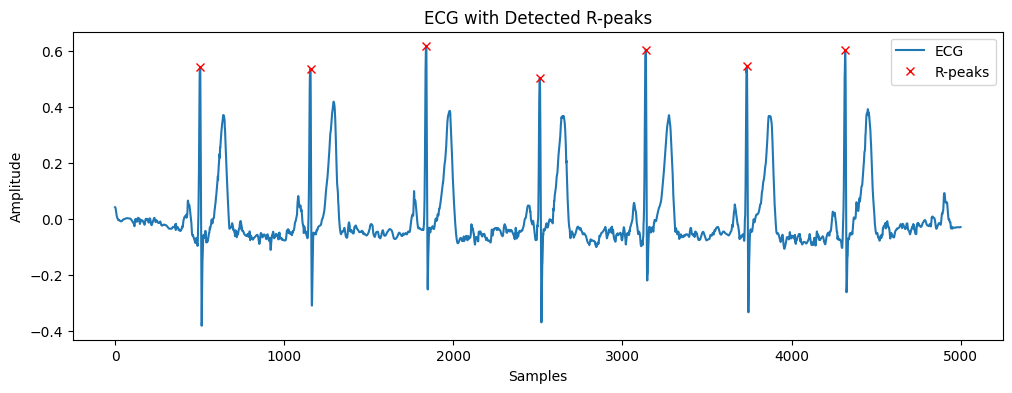

In [333]:
# Optional: Plot the signal with detected peaks
plt.figure(figsize=(12, 4))
plt.plot(signal, label='ECG')
plt.plot(peaks, signal[peaks], "rx", label='R-peaks')
plt.title('ECG with Detected R-peaks')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

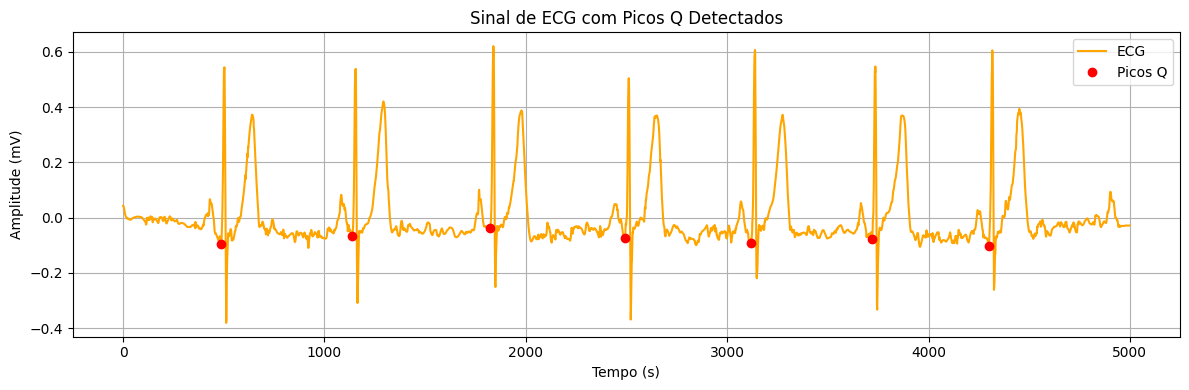

In [339]:
ecg_f = signal
r_peaks = peaks


q_index = []
for i in range(len(r_peaks)):
    q_index.append(np.argmin(ecg_f[max(r_peaks[i]-20,0):r_peaks[i]]) + max(r_peaks[i]-20,0))


plt.figure(figsize=(12, 4))
plt.plot(ecg_f, label='ECG', color='orange')
plt.plot(q_index, ecg_f[q_index], 'ro', label='Picos Q')
plt.title('Sinal de ECG com Picos Q Detectados')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()